In [54]:
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import numpy as np
import anndata as ad
import re
import warnings
import scvelo as scv
from cellbender.remove_background.downstream import anndata_from_h5
from pathlib import Path

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

# Merge additional metadata

In [65]:
scdir = "/research/groups/northcgrp/home/common/Vincentius/scbarcode/counts/scrna/"
samples = [p.name for p in Path(scdir).iterdir() if p.is_dir()]

In [ ]:
batchdict = {}
for sample in samples:
    cellbenderpath = f"{scdir}/{sample}/cellbender/cellbender_output.h5"
    dropletqcpath = f"{scdir}/{sample}/dropletqc/nf_ed_qc.csv"
    velocytopath = f"{scdir}/{sample}/velocyto/{sample}.loom"
    # read all metadata and merge
    cellbender_filtered = anndata_from_h5(cellbenderpath)
    dropletqcdf = pd.read_csv(dropletqcpath, index_col=0)
    vadata = sc.read(velocytopath)
    cellbender_filtered.obs = cellbender_filtered.obs.merge(dropletqcdf, left_index=True, right_index=True, how="left")
    cellbender_filtered = cellbender_filtered[~pd.isna(cellbender_filtered.obs['nf'])].copy()
    cellbender_filtered = scv.utils.merge(cellbender_filtered, vadata)
    # add sample information to cell names
    cellbender_filtered.obs.index = cellbender_filtered.obs.index + "_" + sample
    cellbender_filtered.var_names_make_unique()
    batchdict[sample] = cellbender_filtered
merged_adata = ad.concat(batchdict, join='outer', label="batch_names")
merged_adata.obs_names_make_unique()
merged_adata.var_names_make_unique()
merged_adata.write(f"{scdir}/merged_adata.h5ad")


# Remove ambient RNA

In [46]:
merged_adata = sc.read(f"{scdir}/merged_adata.h5ad")
print((merged_adata.obs.batch_names).unique())
merged_adata = merged_adata[:, merged_adata.var_names.str.startswith("GRCh38_")].copy()
merged_adata.var_names = merged_adata.var_names.str.replace("^GRCh38_", "", regex=True)
merged_adata

['3448773_SJNBT3_SP_8470_10xGEMXsnRNA', '3448774_SJNBT3_PT_CB_8470_10xGEMXsnRNA']
Categories (2, object): ['3448773_SJNBT3_SP_8470_10xGEMXsnRNA', '3448774_SJNBT3_PT_CB_8470_10xGEMXsnRNA']


AnnData object with n_obs × n_vars = 45944 × 38606
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'nf', 'umi', 'cell_status', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'batch_names'
    obsm: 'gene_expression_encoding'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

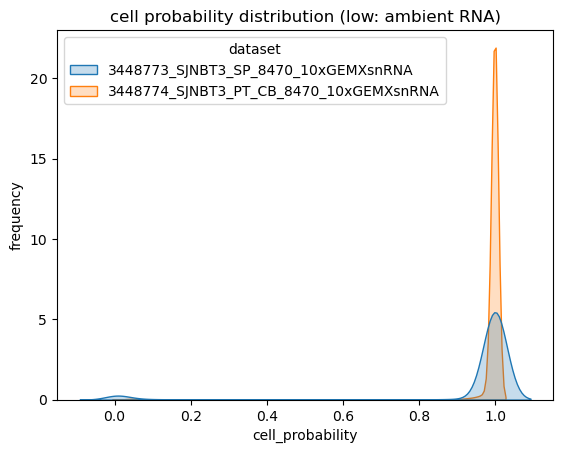

In [48]:
ax = sns.kdeplot(data = merged_adata.obs[['cell_probability', "batch_names"]], 
                 x = 'cell_probability',fill=True, color='blue', hue = "batch_names")  
plt.title("cell probability distribution (low: ambient RNA)")
plt.xlabel("cell_probability")
plt.ylabel("frequency")
sns.move_legend(ax, "upper left", title='dataset')
plt.show()

In [52]:
adata = merged_adata[merged_adata.obs['cell_probability']  > 0.8]
adata

View of AnnData object with n_obs × n_vars = 44379 × 38606
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'nf', 'umi', 'cell_status', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'batch_names'
    obsm: 'gene_expression_encoding'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

# Filter count matrices

In [53]:
adata.var['mito']=adata.var_names.str.startswith("MT-") 
adata.var['ribo']=adata.var_names.str.startswith(('RPL', 'RPS')) 
sc.pp.calculate_qc_metrics(adata, inplace=True, qc_vars = ['mito', 'ribo'], percent_top=None, log1p = False)

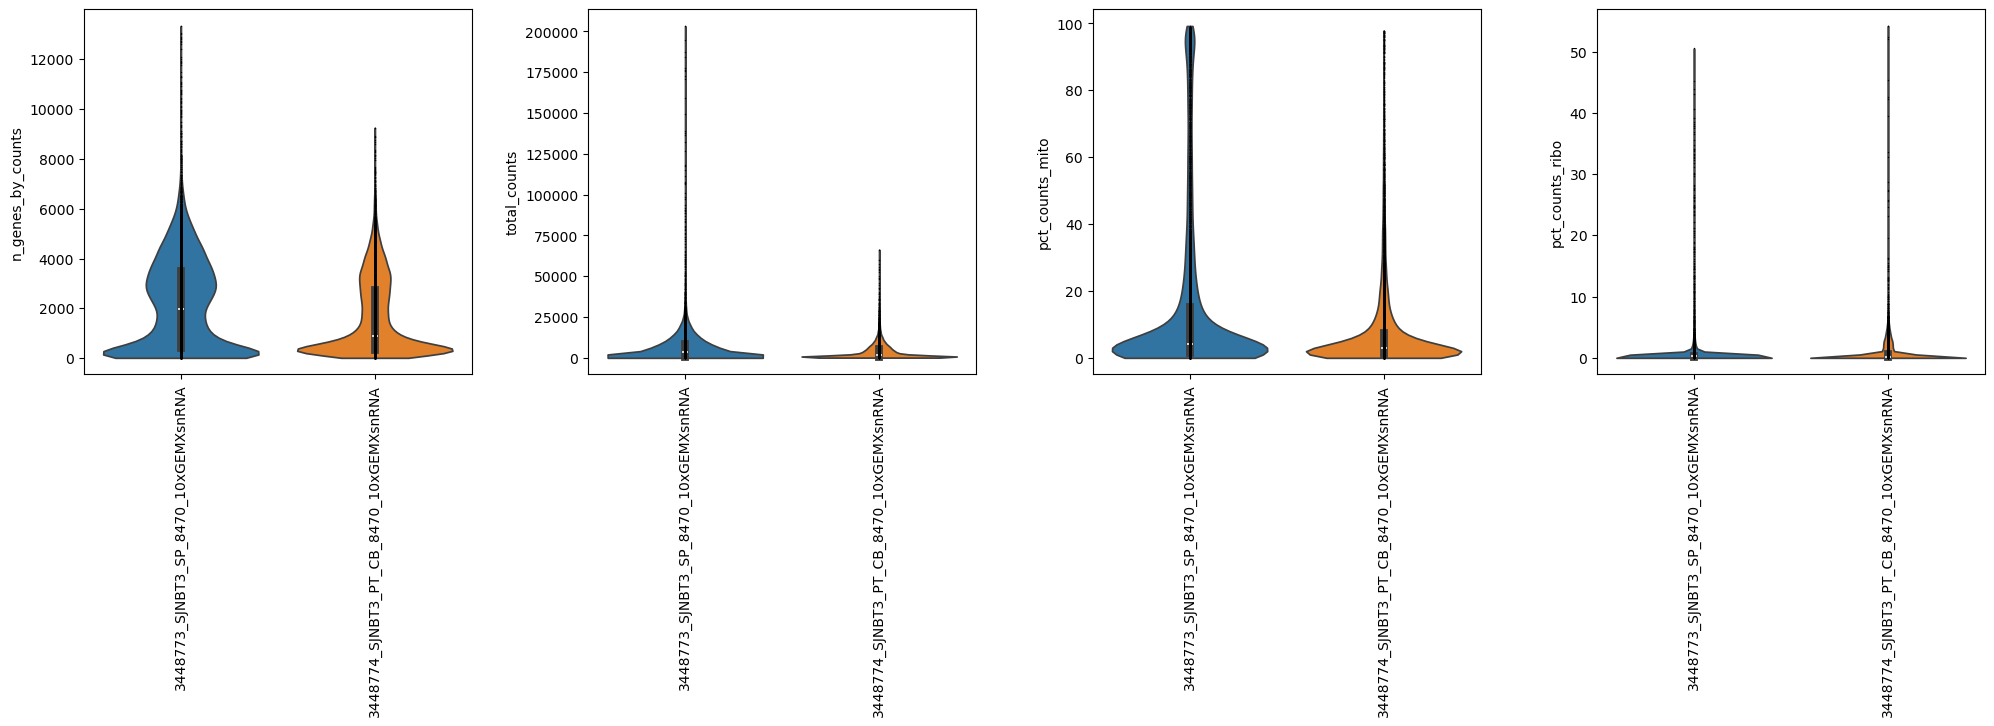

In [57]:
matplotlib.rcParams['figure.figsize'] = [5,5]
sc.pl.violin(adata, groupby="batch_names",
             keys=["n_genes_by_counts", "total_counts",  "pct_counts_mito",'pct_counts_ribo'], 
             multi_panel=True, rotation=90, jitter=False, inner='box')

In [64]:
adata_filtered = adata[(adata.obs["pct_counts_mito"] < 10) & 
                      (adata.obs["total_counts"] < 30000) &
                      (adata.obs["n_genes_by_counts"] < 8000) &
                      (adata.obs["pct_counts_ribo"] < 1)]
adata_filtered

View of AnnData object with n_obs × n_vars = 28536 × 38606
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'nf', 'umi', 'cell_status', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'batch_names', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'batch_names_colors'
    obsm: 'gene_expression_encoding'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

# Filter on DropletQC metrics

<Figure size 800x600 with 0 Axes>

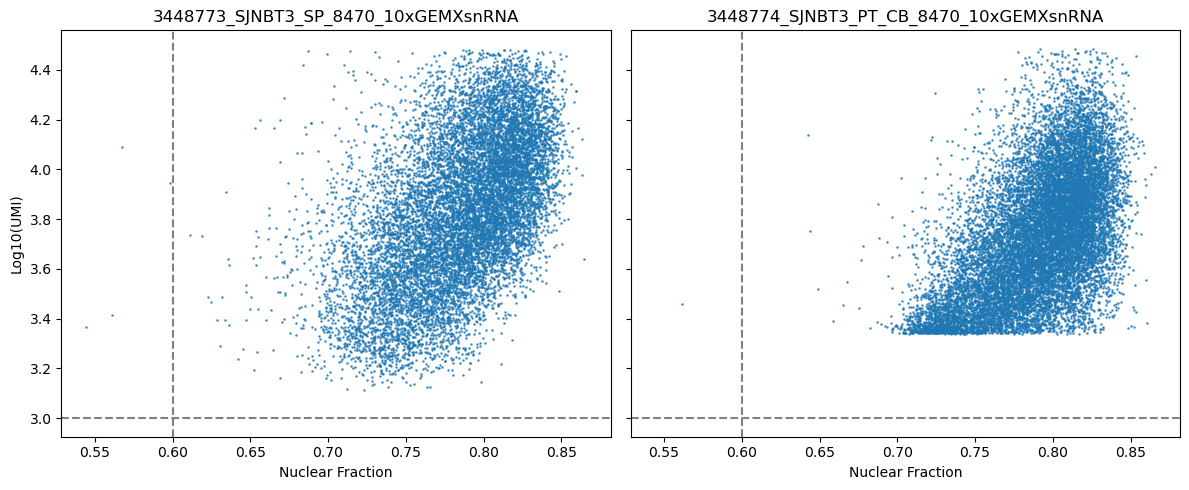

In [68]:
# single-nucleus: 0.6; single-cell: 0.1
nfcutoff = 0.6 
plt.figure(figsize=(8, 6))
fig, axes = plt.subplots(1, len(samples), figsize=(6*len(samples), 5), sharex=True, sharey=True)
if len(samples) == 1:
    axes = [axes]
for ax, sample in zip(axes, samples):
    cur = adata_filtered.obs.query("batch_names == @sample")
    ax.scatter(cur["nf"], np.log10(cur["umi"]), s=0.8, alpha=0.7)
    ax.axvline(0.6, color="gray", ls="--")
    ax.axhline(3, color="gray", ls="--")
    ax.set_title(sample)
    ax.set_xlabel("Nuclear Fraction")
    ax.grid(False)
axes[0].set_ylabel("Log10(UMI)")
plt.tight_layout()
plt.show()

In [70]:
adata_filtered = adata_filtered[(adata_filtered.obs["nf"] > 0.6)]
adata_filtered

View of AnnData object with n_obs × n_vars = 28531 × 38606
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'nf', 'umi', 'cell_status', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'batch_names', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'batch_names_colors'
    obsm: 'gene_expression_encoding'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

# Filter doublet

In [ ]:
sce.pp.scrublet(adata_filtered, batch_key="batch_names")
adata_filtered.obs[['predicted_doublet']].value_counts()

In [75]:
adata_filtered.write(f"{scdir}/filtered_adata.h5ad")

# Run scanpy workflow

In [124]:
adata = sc.read(f"{scdir}/filtered_adata.h5ad")
adata = adata[:, ~(
    adata.var_names.str.startswith(
        ("MT-", "RPS", "RPL", "ENSG", "OR")
    )
)].copy()


In [125]:
# 1. Count normalize
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True, exclude_highly_expressed = True)
sc.pp.log1p(adata)
adata.layers["log1p_norm"] = adata.X.copy()

In [126]:
# 2. Cell cycle scoring
cellcyclepath = "/research/groups/northcgrp/home/common/Rachel/data/genesets/regev_lab_cell_cycle_genes.txt"
cell_cycle_genes = [x.strip() for x in open(cellcyclepath)]
s_genes = [x for x in cell_cycle_genes[:43] if x in adata.var_names]
g2m_genes = [x for x in cell_cycle_genes[43:] if x in adata.var_names]
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)


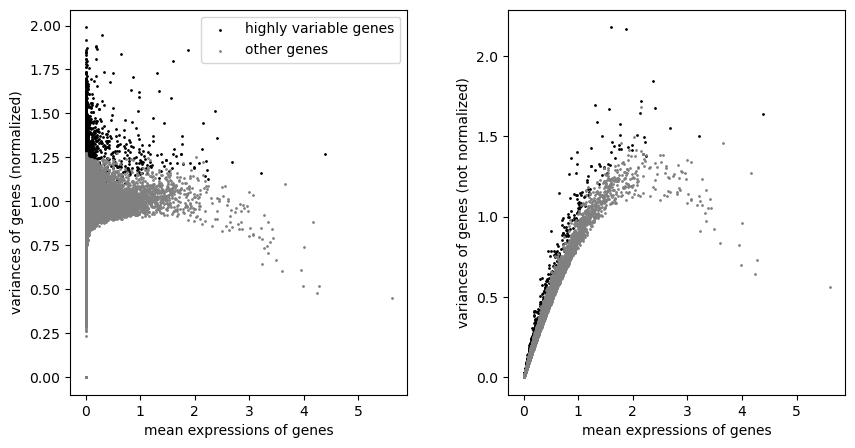

In [127]:
# 3. HVG
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key="batch_names", flavor="seurat_v3")
sc.pl.highly_variable_genes(adata)
adata.raw = adata


In [128]:
# 4. Regress out cell cycle
adata.obs["CC_Difference"] = adata.obs["S_score"] - adata.obs["G2M_score"]
sc.pp.regress_out(adata, keys=["CC_Difference"])
sc.pp.scale(adata, max_value=10)

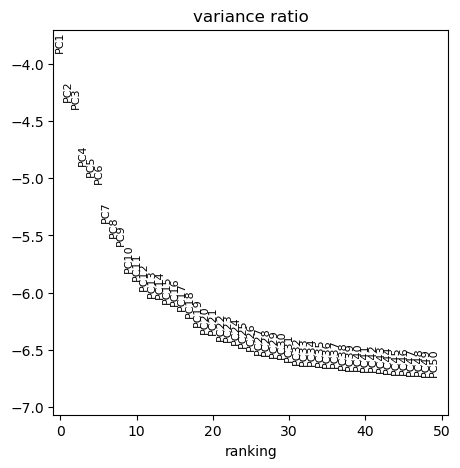

In [129]:
# 5. Dimensionality reduction
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [130]:
# 6. Nearest neighbor graph
sc.pp.neighbors(adata, n_neighbors=40, metric="cosine")
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1)

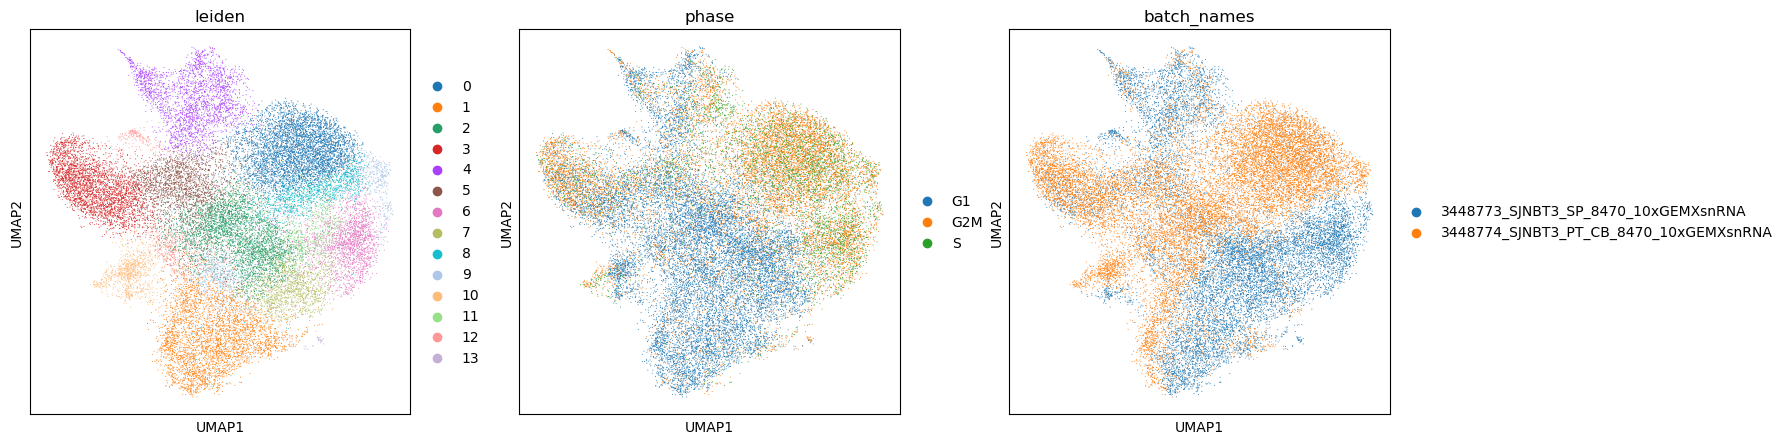

In [131]:
sc.pl.umap(adata, color=["leiden","phase","batch_names"], size=2)

In [138]:
# 7. Find markers
sc.tl.rank_genes_groups(adata, key_added="wilcoxon", method="wilcoxon", pts=True, groupby="leiden", tie_correct=True)

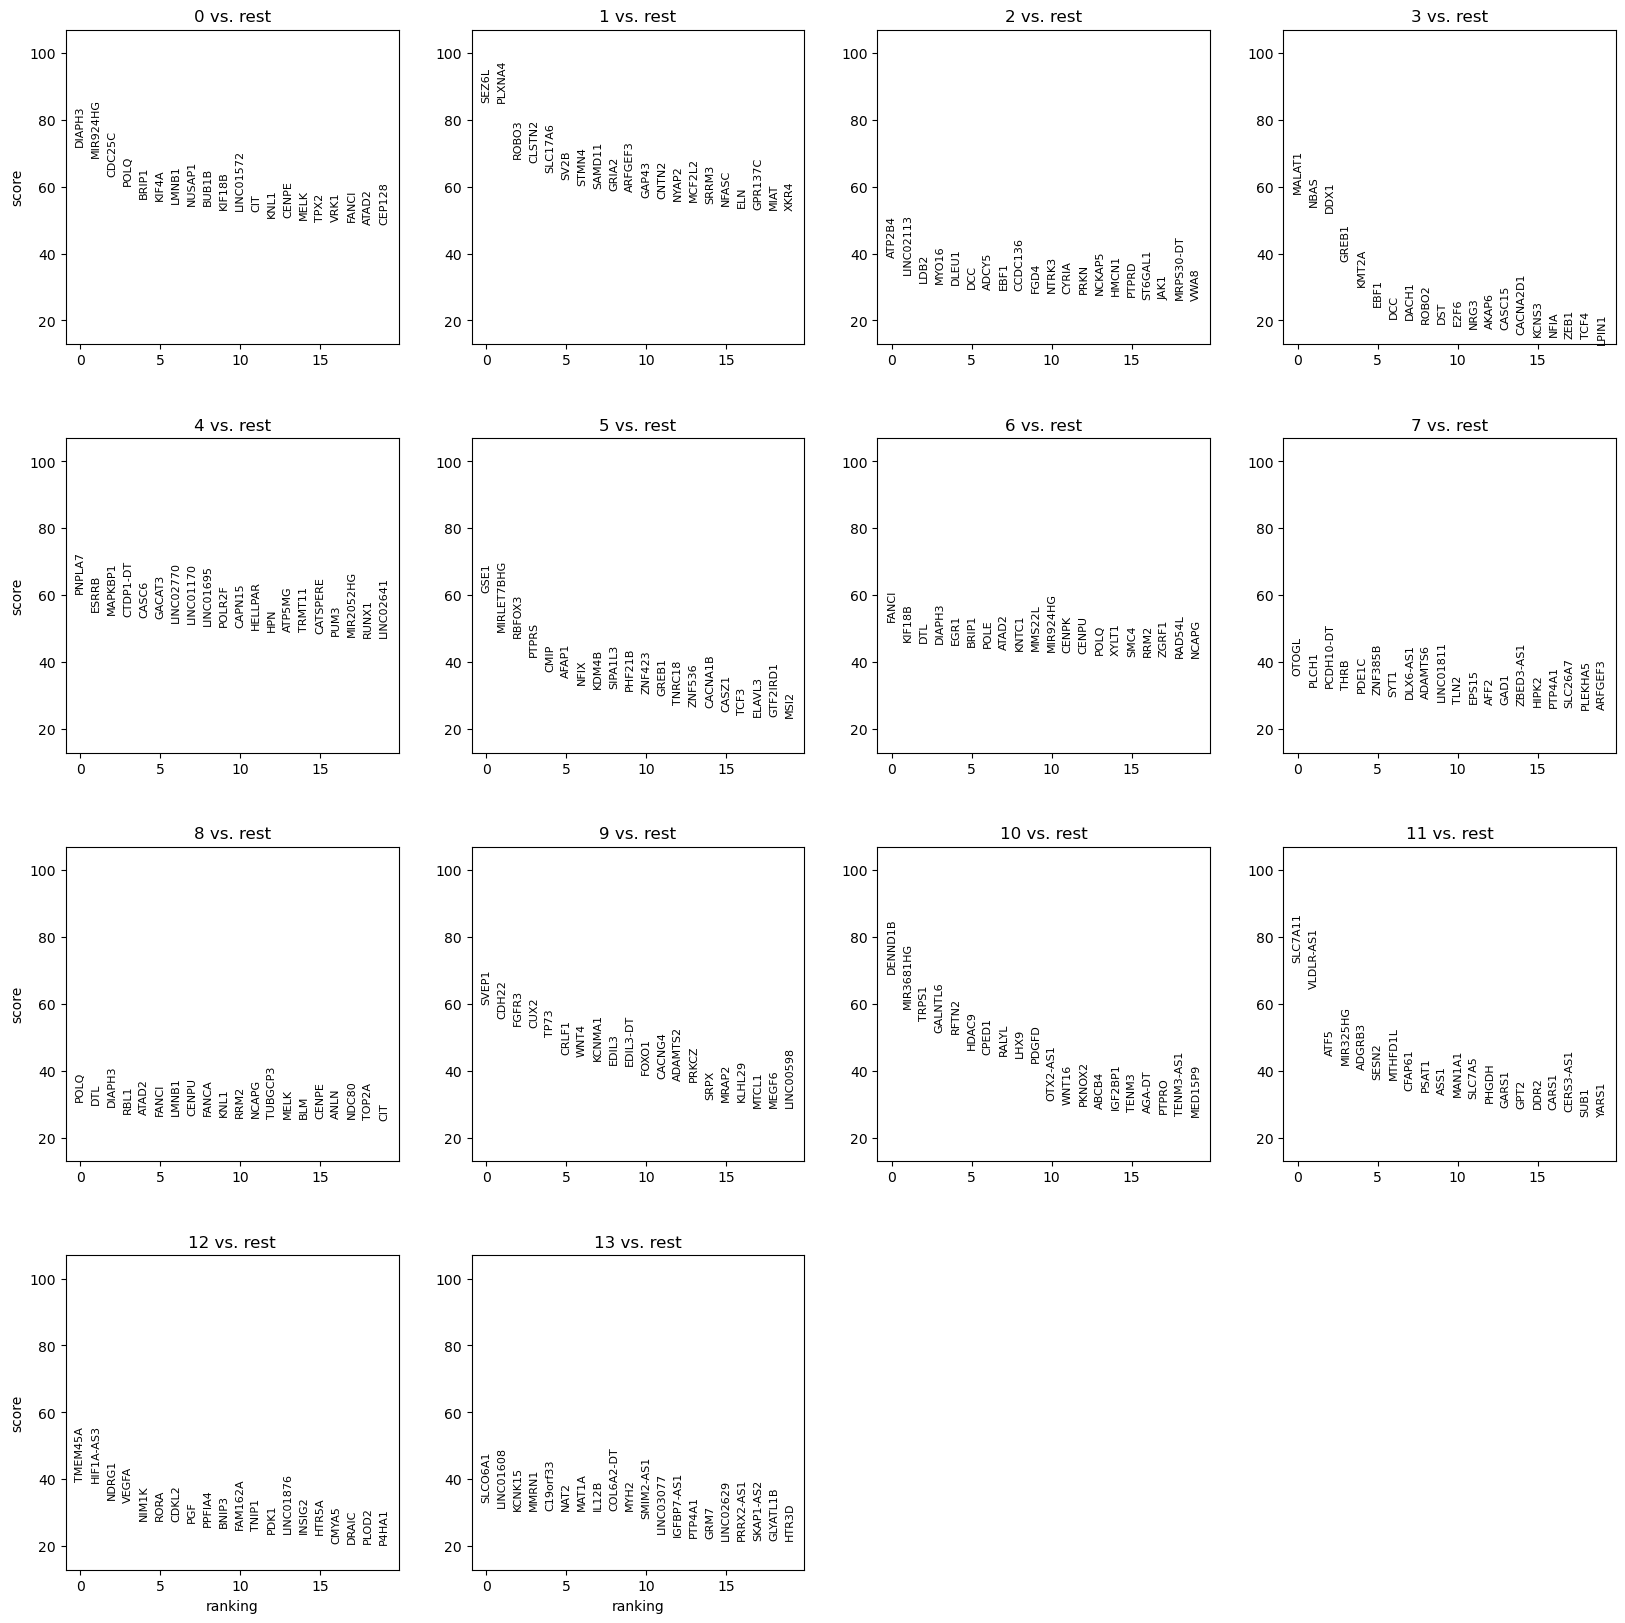

In [139]:
sc.pl.rank_genes_groups(adata, key="wilcoxon")

In [ ]:
for g in adata.obs["leiden"].cat.categories:
    print(g)
    display(sc.get.rank_genes_groups_df(adata, key="wilcoxon", group=g).head(3))

# Cell type annotation

In [132]:
marker_dict = {
    # core neurons
    "neurons": ["RBFOX3", "SNAP25", "SYT1", "PTPRS"],

    # excitatory glutamatergic / projection neurons
    "excitatory_neurons": ["SLC17A6", "ROBO3", "PLXNA4", "CUX2"],

    # inhibitory interneurons
    "inhibitory_neurons": ["GAD1", "GAD2", "PAX2"],

    # cerebellar-like programs
    "cerebellar_neurons": ["PCP2", "CALB1"],  # RELN/ATOH1 not supported by your data

    # glia
    "astrocytes": ["GFAP", "AQP4", "SLC1A3"],
    "oligodendrocytes": ["MBP", "MOG", "PLP1"],
    "opc": ["PDGFRA", "CSPG4", "OLIG2"],

    # immune
    "microglia": ["P2RY12", "CX3CR1", "AIF1"],

    # vascular
    "endothelial": ["PECAM1", "CLDN5"],
    "pericytes": ["RGS5", "PDGFRB"],

    # progenitor / tumor stem-like
    "progenitor": ["SOX2", "NES", "VIM", "ESRRB"],

    # cycling / tumor proliferation (VERY IMPORTANT in your data)
    "cycling": ["CDC25C", "POLQ", "FANCI", "DTL", "KIF18B"],

    # stress / hypoxia tumor state
    "hypoxia_stress": ["VEGFA", "HIF1A-AS3", "NDRG1", "SLC7A11"],

    # neuronal stress / plasticity
    "neuronal_stress": ["MALAT1", "DDX1", "EGR1"]
}

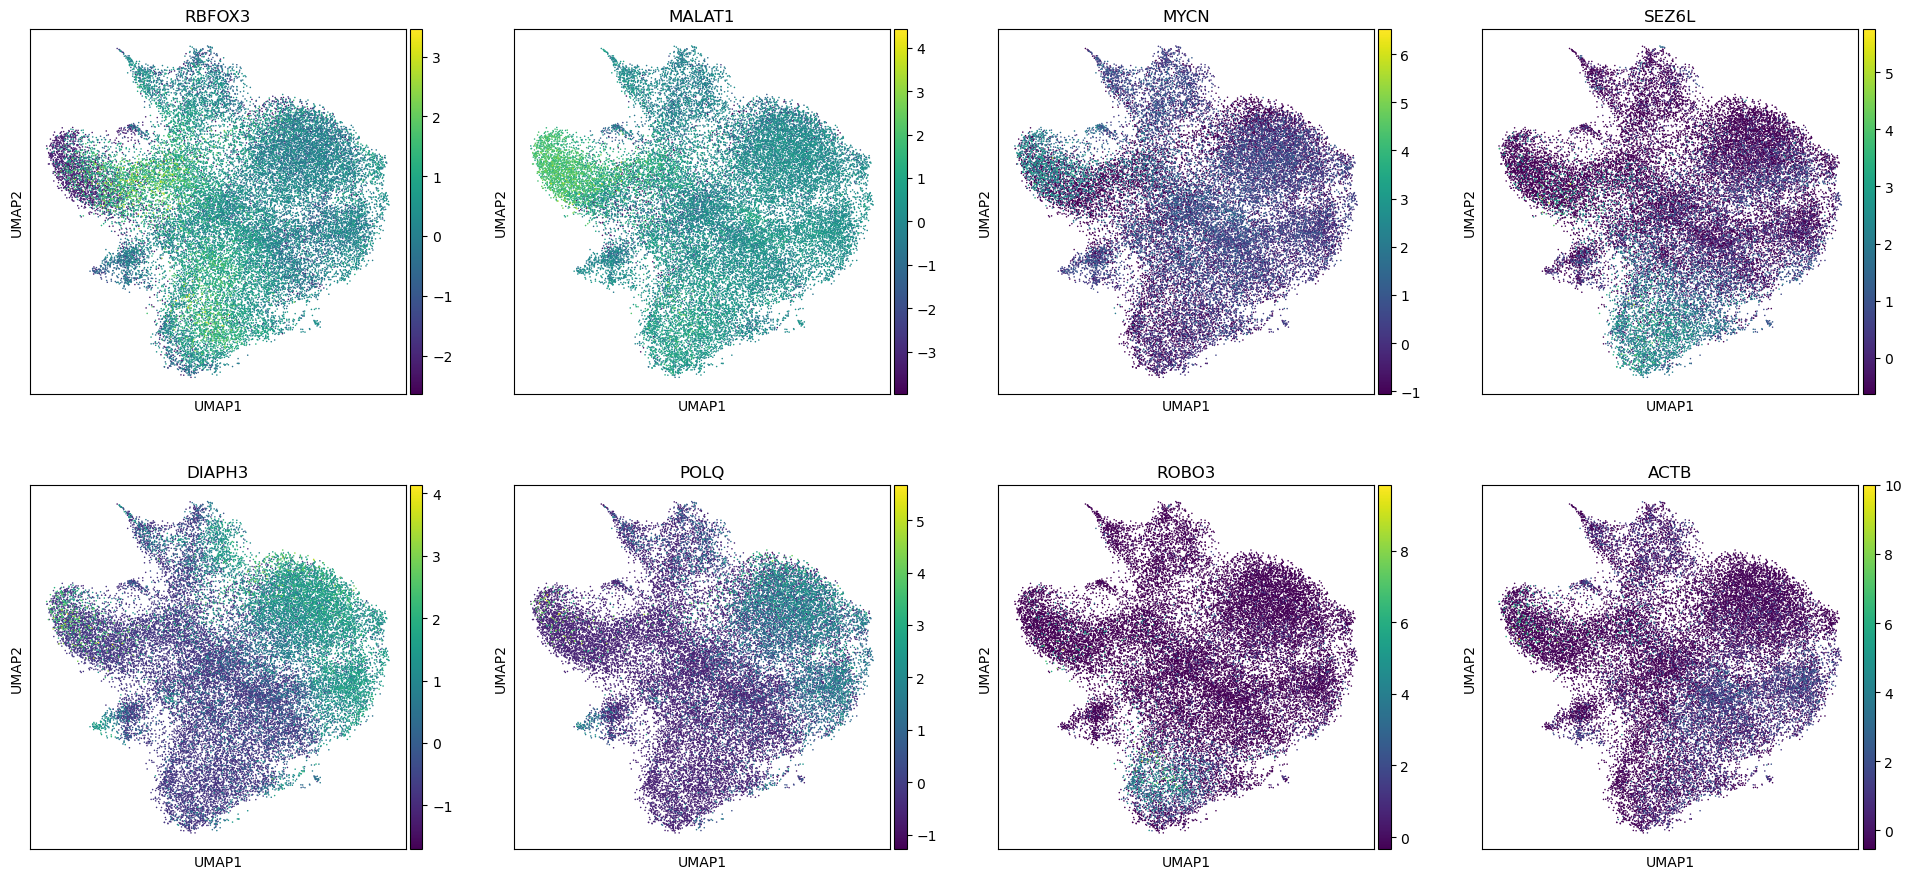

In [211]:
# Plot marker genes
sc.pl.umap(adata, color=['RBFOX3', 'MALAT1','MYCN','SEZ6L','DIAPH3',"POLQ","ROBO3","ACTB"], use_raw=False, s=5)

In [135]:
for ct, genes in marker_dict.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"{ct}_score")
score_cols = [f"{k}_score" for k in marker_dict.keys()]
adata.obs["celltype"] = adata.obs[score_cols].idxmax(axis=1).str.replace("_score", "")

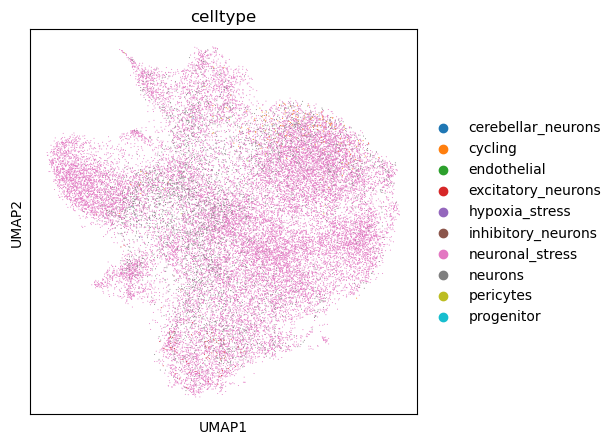

In [136]:
sc.pl.umap( adata, color=["celltype"],  size=2, legend_loc="right margin" )

# Visualize cell barcode

In [176]:
adata.obs["barcode"] = (
    adata.obs_names.str.split("_").str[0] + adata.obs["sample_batch"].astype(str)
)

In [182]:
dfs = []
for s in samples:
    df = pd.read_csv(f"{scdir}/{s}/barcodes/bcanotcb.csv")
    df = df.rename(columns={"barcode":"sticrbarcode","cellbarcode":"barcode"})
    df["batch_names"] = s
    dfs.append(df)
bcdf = pd.concat(dfs, ignore_index=True)
bcdf = bcdf[~bcdf["sticrbarcode"].astype(str).str.contains(r"\*", na=False)]
bcdf = bcdf[["sticrbarcode", "barcode", "batch_names"]].drop_duplicates()
bcdf = bcdf[bcdf["barcode"].isin(adata.obs["barcode"])]

In [206]:
bcdf[["sticrbarcode"]].value_counts().sort_values(ascending=False)
bcdf[bcdf["sticrbarcode"] == "Bit1_F_313-Bit2_F_029-Bit3_F_140"]

,sticrbarcode,barcode,batch_names
2108,Bit1_F_313-Bit2_F_029-Bit3_F_140,GTTATGGTCTAAGTGT-1,3448773_SJNBT3_SP_8470_10xGEMXsnRNA
2122,Bit1_F_313-Bit2_F_029-Bit3_F_140,TGAAACCCACCTGGAA-1,3448773_SJNBT3_SP_8470_10xGEMXsnRNA
2136,Bit1_F_313-Bit2_F_029-Bit3_F_140,TCCATTATCATCTAGG-1,3448773_SJNBT3_SP_8470_10xGEMXsnRNA
2137,Bit1_F_313-Bit2_F_029-Bit3_F_140,CGATTAGTCTAGGCCG-1,3448773_SJNBT3_SP_8470_10xGEMXsnRNA
2144,Bit1_F_313-Bit2_F_029-Bit3_F_140,AGGACCAAGCTGAGTC-1,3448773_SJNBT3_SP_8470_10xGEMXsnRNA


In [205]:
bcdf[bcdf["sticrbarcode"].isin(
    bcdf.groupby("sticrbarcode")["batch_names"].nunique().loc[lambda x: x > 1].index
)]

,sticrbarcode,barcode,batch_names
453,Bit1_F_051-Bit2_F_061-Bit3_F_166,TGAATCCGTTGTCCAG-1,3448773_SJNBT3_SP_8470_10xGEMXsnRNA
2606,Bit1_F_423-Bit2_F_247-Bit3_F_257,GCATAACCAATTCGCC-1,3448773_SJNBT3_SP_8470_10xGEMXsnRNA
3849,Bit1_F_051-Bit2_F_061-Bit3_F_166,ACTGCAATCCCATTCG-1,3448774_SJNBT3_PT_CB_8470_10xGEMXsnRNA
5168,Bit1_F_423-Bit2_F_247-Bit3_F_257,CTACGAATCCGCCATC-1,3448774_SJNBT3_PT_CB_8470_10xGEMXsnRNA


2606    GCATAACCAATTCGCC-1
5168    CTACGAATCCGCCATC-1
Name: barcode, dtype: object


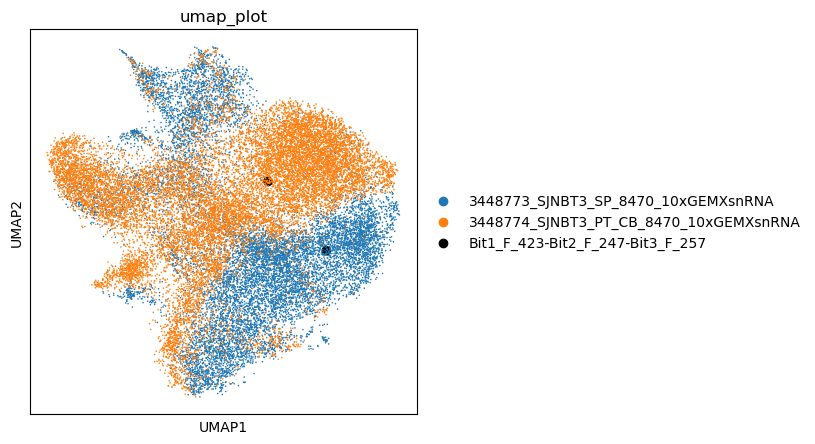

In [207]:
target = "Bit1_F_423-Bit2_F_247-Bit3_F_257"
bcs = bcdf.loc[bcdf["sticrbarcode"] == target, "barcode"]
print(bcs)
adata.obs["is_target"] = adata.obs["barcode"].isin(bcs)
adata.obs["umap_plot"] = adata.obs["batch_names"].astype(str)
adata.obs.loc[adata.obs["is_target"], "umap_plot"] = target
sc.pl.umap(adata, color="umap_plot", palette={**dict(zip(adata.obs["batch_names"].unique(), 
                                                         sc.pl.palettes.default_20)), target:"black"}, 
                                                         size=adata.obs["is_target"].map({True:200, False:5}).values)